<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK11_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 7.6 게이트 순환 신경망(GRU)

GRU(Gated Recurrent Unit): 게이트 메커니즘이 적용된 RNN 프레임워크의 한 종류이면서 LSTM보다 구조가 간단.

### 7.6.1 GRU 구조

GRU: 망각게이트와 입력게이트를 하나로 합친 것. 별도의 업데이트게이트로 구성. 하나의 게이트 컨트롤러가 망각게이트와 입력게이트를 모두 제어.
- 1 출력: 망각게이트 열림, 입력게이트 닫힘.
- 0 출력: 망각게이트 닫힘, 입력게이트 열림.

**망각게이트**: 과거 정보를 적당히 초기화시키려는 목적으로 시그모이드 함수를 출력으로 이용. (0, 1) 값을 이전 은닉층에 곱함.

**업데이트게이트**: 과거와 현재 정보의 최신화 비율을 결정하는 역할.

**후보군**(candidate): 현시점의 정보에 대한 후보군 계산. 과거의 은닉층의 정보를 그대로 이용하지 않고 망각 게이트의 결과를 이용해 후보군 계산.

**은닉층 계산**: 업데이트게이트 결과와 후보군 결과를 결합해 현시점의 은닉층을 계산.
- 시그모이드 함수의 결과: 현시점에서 결과에 대한 정보량 결정.
- 1-시그모이드 함수: 과거의 정보량 결정.

### 7.6.2 GRU 셀 구현

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

cuda=True if torch.cuda.is_available() else False

Tensor=torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

In [3]:
# 코드 7-53 데이터 전처리
mnist_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,))
])

In [5]:
# 코드 7-54 데이터셋 내려받기 및 전처리 적용
from torchvision.datasets import MNIST
download_root='../chap07/MNIST_DATASET'

train_dataset=MNIST(download_root,transform=mnist_transform,train=True,download=True)
valid_dataset=MNIST(download_root,transform=mnist_transform,train=True,download=True)
test_dataset=MNIST(download_root,transform=mnist_transform,train=False,download=True)

In [6]:
# 코드 7-55 데이터셋 메모리로 가져오기
batch_size=64
train_loader=DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
valid_loader=DataLoader(dataset=valid_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

In [7]:
# 7-56 변수 값 설정
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

In [12]:
# 7-57 GRU 셀 네트워크
class GRU(nn.Module):
  def __init__(self,input_size,hidden_size,bias=True):
    super(GRU,self).__init__() # FIX: Changed GRUCell to GRU
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.bias=bias
    self.x2h=nn.Linear(input_size,3*hidden_size,bias=bias)
    self.h2h=nn.Linear(hidden_size,3*hidden_size,bias=bias)
    self.reset_parameters()

  def reset_parameters(self):
    std=1.0/math.sqrt(self.hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std,std)

  def forward(self,x,hidden):
    x=x.view(-1,x.size(1))

    gate_x=self.x2h(x)
    gate_h=self.h2h(hidden)

    gate_x=gate_x.squeeze()
    gate_h=gate_h.squeeze()

    i_r,i_i,i_n=gate_x.chunk(3,1)
    h_r,h_i,h_n=gate_h.chunk(3,1)

    resetgate=F.sigmoid(i_r+h_r)
    inputgate=F.sigmoid(i_i+h_i)
    newgate=F.tanh(i_n+(resetgate*h_n))

    hy=newgate+inputgate*(hidden-newgate)
    return hy

In [13]:
# 코드 7-58 전반적인 네트워크 구조
class GRUModule(nn.Module):
  def __init__(self,input_dim,hidden_dim,layer_dim,output_dim,bias=True):
    super(GRUModule,self).__init__()
    self.hidden_dim=hidden_dim
    self.layer_dim=layer_dim

    # FIX: Changed GRUCell to GRU and removed layer_dim as GRU doesn't accept it
    self.gru_cell=GRU(input_dim,hidden_dim)
    self.fc=nn.Linear(hidden_dim,output_dim)

  def forward(self,x):
    # FIX: Corrected .cuda() call for tensor initialization
    if torch.cuda.is_available():
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim)).cuda()
    else:
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim))

    outs=[]
    hn=h0[0,:,:]

    for seq in range(x.size(1)):
      hn=self.gru_cell(x[:,seq,:],hn)
      outs.append(hn)

    # FIX: Moved return statement outside the loop
    out=outs[-1].squeeze()
    out=self.fc(out)
    return out

In [14]:
# 코드 7-59 옵티마이저와 손실 함수 설정
input_dim=28
hidden_dim=128
layer_dim=1
output_dim=10

model=GRUModule(input_dim,hidden_dim,layer_dim,output_dim)

if torch.cuda.is_available():
  model.cuda()

criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [16]:
# 코드 7-60 모델 학습 및 성능 검증
seq_dim=28
loss_list=[]
iteration = 0 # FIX: Renamed 'iter' to 'iteration' to avoid conflict with built-in function
for epoch in range(num_epochs):
  for i,(images,labels) in enumerate(train_loader):
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels=Variable(labels.cuda())
    else:
      images=Variable(images.view(-1,seq_dim,input_dim))
      labels=Variable(labels)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)

    # if torch.cuda.is_available(): # FIX: Removed unnecessary loss.cuda() call
    #   loss.cuda()

    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    iteration+=1 # FIX: Updated variable name

    if iteration%500==0: # FIX: Updated variable name
      correct=0
      total=0
      for images,labels in valid_loader: # FIX: Corrected typo 'valid_oader' to 'valid_loader'
        if torch.cuda.is_available():
          images=Variable(images.view(-1,seq_dim,input_dim).cuda())
        else:
          images=Variable(images.view(-1,seq_dim,input_dim))

        outputs=model(images)
        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)

        if torch.cuda.is_available():
          correct+=(predicted.cpu()==labels.cpu()).sum()
        else:
          correct+=(predicted==labels).sum()

      accuracy=100*correct/total # FIX: Moved accuracy calculation and print inside the if block
      print('Iteration:{}. Loss:{}. Accuracy:{}'.format(iteration,loss.item(),accuracy)) # FIX: Updated variable name

Iteration:500. Loss:1.66169273853302. Accuracy:43.70833206176758
Iteration:1000. Loss:0.8945668339729309. Accuracy:75.47333526611328
Iteration:1500. Loss:0.29147759079933167. Accuracy:89.46499633789062
Iteration:2000. Loss:0.23627924919128418. Accuracy:93.21499633789062
Iteration:2500. Loss:0.032887257635593414. Accuracy:94.73500061035156
Iteration:3000. Loss:0.030374977737665176. Accuracy:95.8949966430664
Iteration:3500. Loss:0.16210564970970154. Accuracy:96.37666320800781
Iteration:4000. Loss:0.193087637424469. Accuracy:96.5566635131836
Iteration:4500. Loss:0.051720064133405685. Accuracy:97.1066665649414
Iteration:5000. Loss:0.13900160789489746. Accuracy:97.40333557128906
Iteration:5500. Loss:0.08090295642614365. Accuracy:97.75499725341797
Iteration:6000. Loss:0.10488356649875641. Accuracy:97.89833068847656
Iteration:6500. Loss:0.07984025776386261. Accuracy:98.07833099365234
Iteration:7000. Loss:0.10250382125377655. Accuracy:98.07333374023438
Iteration:7500. Loss:0.0647798478603363. 

In [19]:
# 코드 7-61 테스트 데이터셋을 이용한 모델 예측
def evaluate(model,val_iter):
  corrects,total,total_loss=0,0,0
  model.eval()
  for images,labels in val_iter:
    # Move both images and labels to the correct device
    images=Variable(images.view(-1,seq_dim,input_dim)).to(device)
    labels=labels.to(device)

    logit=model(images)
    loss=F.cross_entropy(logit,labels,reduction="sum")
    _,predicted=torch.max(logit.data,1)
    total+=labels.size(0)
    total_loss+=loss.item()
    corrects+=(predicted==labels).sum()

  avg_loss=total_loss/len(val_iter.dataset)
  avg_accuracy=corrects/total
  return avg_loss,avg_accuracy

In [20]:
# 코드 7-62 모델 예측 결과
test_loss,test_acc=evaluate(model,test_loader)
print(f'Test Loss: {test_loss:5.2f} | Test Accuracy: {test_acc:5.2f}')

Test Loss:  0.07 | Test Accuracy:  0.98


### 7.6.3 GRU 계층 구현


In [21]:
# 코드 7-63 라이브러리 호출
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
# 코드 7-64 데이터셋 불러오기
!git clone https://github.com/gilbutITbook/080289.git
data_path='080289/chap07/data'
import pandas as pd
data = pd.read_csv(f'{data_path}/SBUX.csv')
print(data.dtypes)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 24.18 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [24]:
# 코드 7-65 인덱스 설정 및 데이터 타입 변경
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)
data['Volume']=data['Volume'].astype(float)

In [25]:
# 코드 7-66 훈련과 레이블 데이터셋 분리
X=data.iloc[:,:-1]
y=data.iloc[:,5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [26]:
# 코드 7-67 훈련과 테스트 데이터셋 정규화
ms=MinMaxScaler()
ss=StandardScaler()

X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)

X_train=X_ss[:200,:]
X_test=X_ss[200:,:]

y_train=y_ms[:200,:]
y_test=y_ms[200:,:]

print("Training Shape",X_train.shape,y_train.shape)
print("Testing Shape",X_test.shape,y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [27]:
# 코드 7-68 데이터셋 형태 변경
X_train_tensors=Variable(torch.Tensor(X_train))
X_test_tensors=Variable(torch.Tensor(X_test))

y_train_tensors=Variable(torch.Tensor(y_train))
y_test_tensors=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensors,(X_train_tensors.shape[0],1,X_train_tensors.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensors,(X_test_tensors.shape[0],1,X_test_tensors.shape[1]))

print("Training Shape",X_train_tensors_f.shape,y_train_tensors.shape)
print("Testing Shape",X_test_tensors_f.shape,y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [28]:
# 코드 7-69 GRU 모델의 네트워크
class GRU(nn.Module):
  def __init__(self,num_classes,inpu_size,hidden_size,num_layers,seq_length):
    super(GRU,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.seq_length=seq_length

    self.gru=nn.GRU(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True)
    self.fc_1=nn.Linear(hidden_size,128)
    self.fc=nn.Linear(128,num_classes)
    self.relu=nn.ReLU()

  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    output,(hn)=self.gru(x,(h_0))
    hn=hn.view(-1,self.hidden_size)
    out=self.relu(hn)
    out=self.fc_1(out)
    out=self.relu(out)
    out=self.fc(out)
    return out

In [29]:
# 코드 7-70 옵티마이저와 손실 함수 지정
num_epochs=1000
learning_rate=0.0001

input_size=5
hidden_size=2
num_layers=1

num_classes=1
model=GRU(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])

criterion=torch.nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [31]:
# 코드 7-71 모델 학습
for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss=criterion(outputs,y_train_tensors)
  loss.backward()

  optimizer.step()
  if epoch%100==0:
    print("Epoch: %d, loss: %1.5f" % (epoch,loss.item()))

Epoch: 0, loss: 0.04374
Epoch: 100, loss: 0.03309
Epoch: 200, loss: 0.03185
Epoch: 300, loss: 0.03090
Epoch: 400, loss: 0.02961
Epoch: 500, loss: 0.02806
Epoch: 600, loss: 0.02617
Epoch: 700, loss: 0.02401
Epoch: 800, loss: 0.02168
Epoch: 900, loss: 0.01978


In [32]:
# 코드 7-72 그래프 출력을 위한 전처리
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,-1:])

df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))

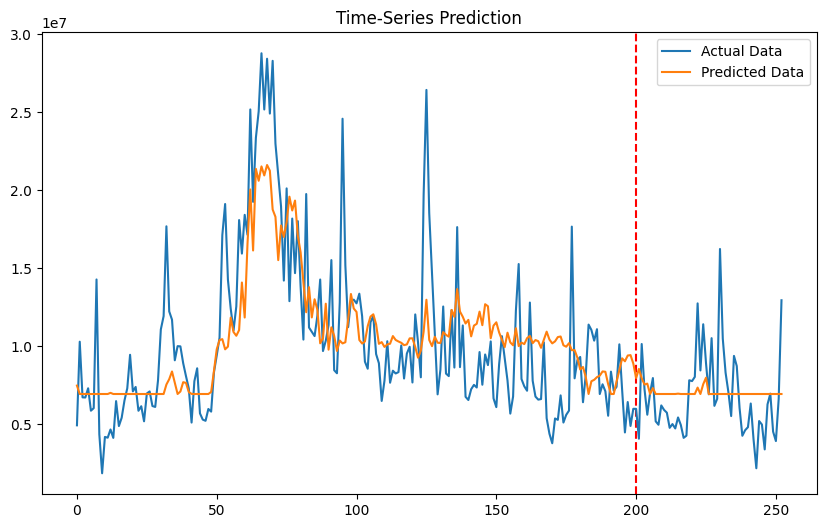

In [33]:
# 코드 7-73 모델 예측 결과 출력
train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')

plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

## 7.7 양방향 RNN

이전 시점 데이터뿐 아니라 이후 시점의 데이터도 함께 활용하여 출력 값을 예측하고자 하는 것.

### 7.7.1 양방향 RNN 구조

양방향 RNN: 하나의 출력 값을 예측하는 데 메모리 셀 두 개를 사용. 첫 번째 메모리 셀은 이전 시점의 은닉 상태를 전달받아 현재의 은닉 상태를 계산. 두 번째 메모리 셀은 다음 시점의 은닉 상태를 전달 받아 현재의 은닉 상태를 계산. 두 값을 출력층에서 출력 값을 예측하는 데 사용.

### 7.7.2 양방향 LSTM 구현

In [35]:
# 코드 7-74 모델을 생성하고 학습
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

!git clone https://github.com/gilbutITbook/080289.git
data_path='080289/chap07/data'
import pandas as pd
data = pd.read_csv(f'{data_path}/SBUX.csv')
print(data.dtypes)

data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)
data['Volume']=data['Volume'].astype(float)

X=data.iloc[:,:-1]
y=data.iloc[:,5:6]

ms=MinMaxScaler()
ss=StandardScaler()

X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)

X_train=X_ss[:200,:]
X_test=X_ss[200:,:]
y_train=y_ms[:200,:]
y_test=y_ms[200:,:]

X_train_tensors=Variable(torch.Tensor(X_train))
X_test_tensors=Variable(torch.Tensor(X_test))

y_train_tensors=Variable(torch.Tensor(y_train))
y_test_tensors=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensors,(X_train_tensors.shape[0],1,X_train_tensors.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensors,(X_test_tensors.shape[0],1,X_test_tensors.shape[1]))

print("Training Shape",X_train.shape,y_train.shape)
print("Testing Shape",X_test.shape,y_test.shape)

fatal: destination path '080289' already exists and is not an empty directory.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [39]:
# 코드 7-75 모델의 네트워크
class biLSTM(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(biLSTM,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.seq_length=seq_length
    self.hidden_size=hidden_size # FIX: Added hidden_size to the constructor and assigned it

    self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,
                      num_layers=num_layers,batch_first=True,bidirectional=True)
    self.fc=nn.Linear(hidden_size*2,num_classes)
    self.relu=nn.ReLU()

  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers*2,x.size(0),self.hidden_size))
    c_0=Variable(torch.zeros(self.num_layers*2,x.size(0),self.hidden_size))
    out,_=self.lstm(x,(h_0,c_0))
    out=self.fc(out[:,-1,:])
    out=self.relu(out)
    return out

입력 데이터가 전방향과 역방향 학습에 모두 전달되며 그 결과들도 모두 출력에 반영됨. 한 번 학습하는 데 두 개의 계층이 필요하기 때문에 LSTM과 다르게 은닉 상태, 셀 상태에 2를 곱하고 마지막 출력층에도 2를 곱해야 함.

In [40]:
# 코드 7-76 모델 학습
num_epochs=1000
learning_rate=0.0001

input_size=5
hidden_size=2
num_layers=1
num_classes=1
model=biLSTM(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])

criterion=torch.nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()

  loss=criterion(outputs,y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch%100==0:
    print("Epoch:%d, loss:%1.5f"%(epoch,loss.item()))

Epoch:0, loss:0.14120
Epoch:100, loss:0.13131
Epoch:200, loss:0.11176
Epoch:300, loss:0.09523
Epoch:400, loss:0.08161
Epoch:500, loss:0.07047
Epoch:600, loss:0.06162
Epoch:700, loss:0.05490
Epoch:800, loss:0.05001
Epoch:900, loss:0.04659


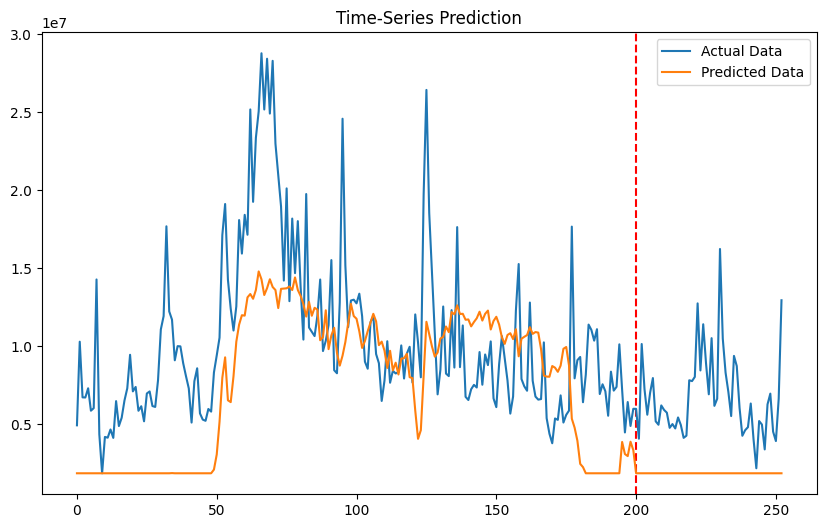

In [41]:
# 코드 7-77 모델 평가
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,-1:])

df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))

train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')

plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()